In [1]:
import sys
import os
import pandas as pd
# Trỏ đường dẫn về thư mục gốc để import src
sys.path.append(os.path.abspath('..'))

from src.data.loader import DataLoader
from src.models.supervised import FailurePredictor

In [2]:
DATA_PATH = '../data/raw/ai4i2020.csv'
loader = DataLoader(DATA_PATH)
df = loader.load_data()

# Mã hóa cột 'Type' (L/M/H) thành số vì Mô hình máy học không hiểu chữ
# L=0, M=1, H=2
df['Type'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})
df.head()

-> Đã load dữ liệu: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,1,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,0,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,0,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,0,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,0,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Số lượng tập train: 8000, Số lượng tập test: 2000
-> Đang huấn luyện mô hình Random Forest...

=== BÁO CÁO ĐÁNH GIÁ (CLASSIFICATION REPORT) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.96      0.98        68

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC Score: 0.9842
F1-Score: 0.9774


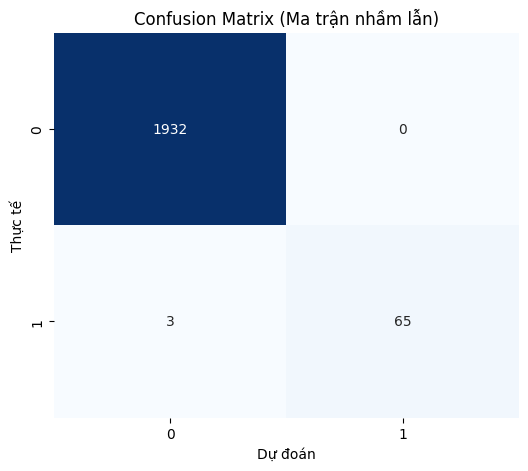

In [3]:
# 1. Khởi tạo mô hình
predictor = FailurePredictor()

# 2. Chia dữ liệu Train/Test
X_train, X_test, y_train, y_test = predictor.prepare_data(df, target_col='Machine failure')
print(f"Số lượng tập train: {X_train.shape[0]}, Số lượng tập test: {X_test.shape[0]}")

# 3. Huấn luyện
predictor.train(X_train, y_train)

# 4. Đánh giá kết quả
predictor.evaluate(X_test, y_test)

c:\Users\Admin\Downloads\BTL_DATA-main\BTL_DATA-main\src\models\supervised.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=indices.values, y=indices.index, palette='viridis')


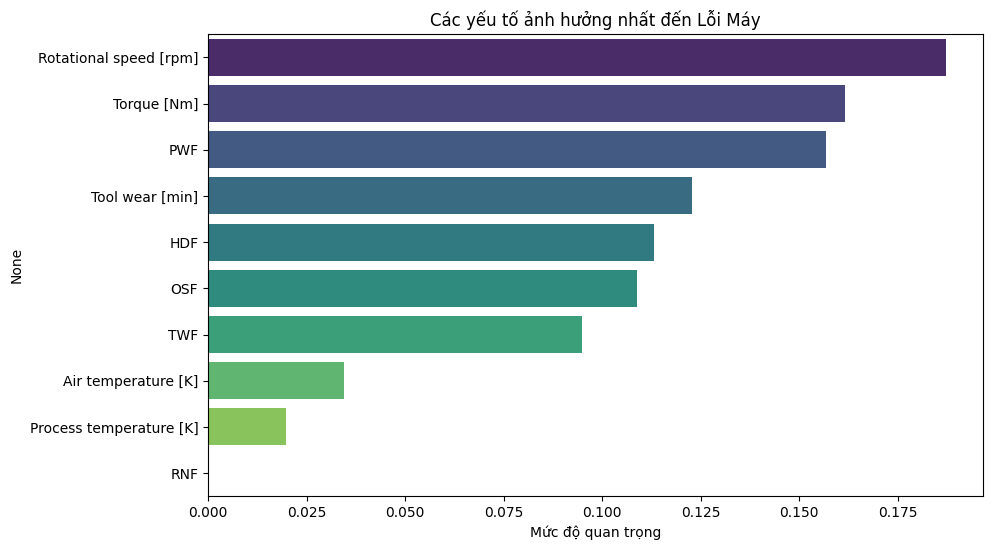

In [4]:
# Xem máy hỏng chủ yếu do nhiệt độ, hay do mòn dao, hay do tốc độ quay?
predictor.feature_importance()

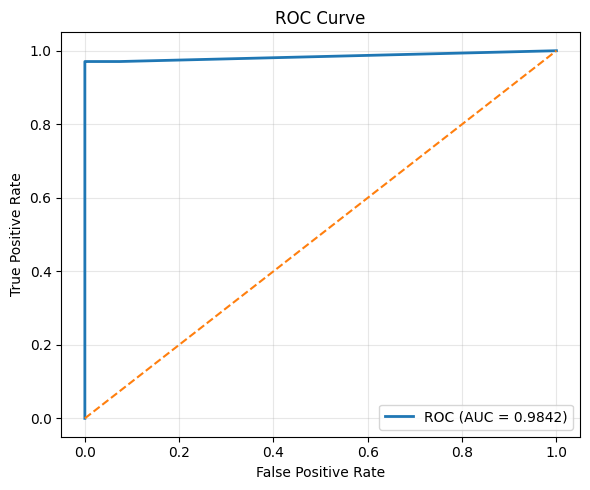

In [17]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

os.makedirs('images', exist_ok=True)

# 🔥 FIX ĐÚNG
y_prob = predictor.model.predict_proba(X_test)[:, 1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('images/roc_curve.png', dpi=300)
plt.show()

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')
MAE: 55.12860499999999
RMSE: 64.67750695991613


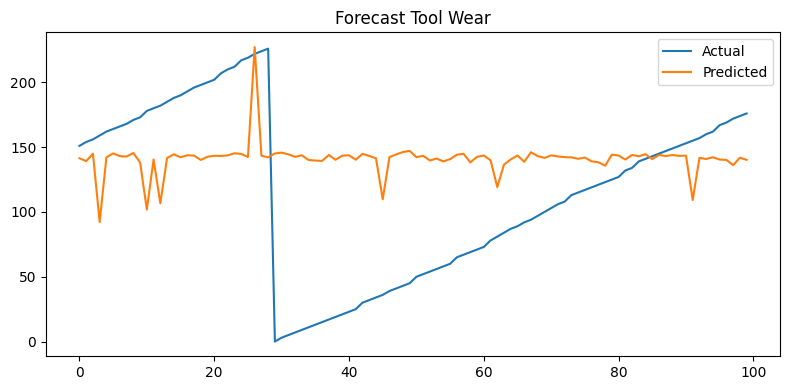

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import os

# ===== FIX DATA =====
df_reg = df.copy()  # dùng df nếu df_processed lỗi

# kiểm tra cột
print(df_reg.columns)

# đảm bảo cột tồn tại
assert 'Tool wear [min]' in df_reg.columns

# loại bỏ cột không cần
X_reg = df_reg.drop(columns=['Tool wear [min]', 'Machine failure'], errors='ignore')
y_reg = df_reg['Tool wear [min]']

# ===== LOẠI CỘT STRING =====
X_reg = X_reg.select_dtypes(include=['number'])

# ===== SPLIT =====
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, shuffle=False
)

# ===== MODEL =====
model_reg = RandomForestRegressor(random_state=42)
model_reg.fit(X_train, y_train)

# ===== PREDICT =====
y_pred = model_reg.predict(X_test)

# ===== METRICS =====
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

# ===== PLOT =====
os.makedirs('images', exist_ok=True)

plt.figure(figsize=(8,4))
plt.plot(y_test.values[:100], label='Actual')
plt.plot(y_pred[:100], label='Predicted')

plt.legend()
plt.title('Forecast Tool Wear')

plt.tight_layout()
plt.savefig('images/forecast.png', dpi=300)
plt.show()

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ===== TARGET =====
y_reg = df['Tool wear [min]']

# ===== FEATURES =====
X_reg = df.drop(columns=['Tool wear [min]', 'Machine failure', 'Product ID'])

# encode categorical
X_reg = pd.get_dummies(X_reg, drop_first=True)

# ===== SPLIT =====
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, shuffle=False
)

# ===== MODEL =====
model_reg = RandomForestRegressor(random_state=42)
model_reg.fit(X_train, y_train)

# ===== PREDICT =====
y_pred = model_reg.predict(X_test)

# ===== METRICS =====
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("===== REGRESSION RESULTS =====")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

===== REGRESSION RESULTS =====
MAE: 55.1286
RMSE: 64.6775
